In [ ]:
import pandas as pd

In [ ]:
data=pd.read_csv('/content/kicksharing.csv')

In [ ]:
data.shape

(396749, 20)

In [ ]:
len(data['order_rk'].unique())

396749

In [ ]:
data.drop(['order_rk'], axis=1, inplace=True)

In [ ]:
for i in ['created_dttm','book_start_dttm','book_end_dttm','local_book_start_dttm']:
  data[i] = pd.to_datetime(data[i])

In [ ]:
data['tz_shift_hours'] = data['book_time_zone_cd'] - 3
data['converted_book_start_dttm'] = data['book_start_dttm'] + pd.to_timedelta(data['tz_shift_hours'], unit='h')
data[data['converted_book_start_dttm'] != data['local_book_start_dttm']]
#проверим на ошибки заполнения. все корректно значит можно и другие колонки подредачить

,party_rk,gender_cd,age,education_level_cd,marital_status_cd,lvn_state_nm,minute_cost,activation_cost,hold_amount,transport_model,...,created_dttm,book_start_dttm,book_end_dttm,book_time_zone_cd,local_book_start_dttm,nominal_price_rub_amt,loyalty_accrual_rub_amt,loyalty_accrual_bns_amt,tz_shift_hours,converted_book_start_dttm


In [ ]:
data.drop(['converted_book_start_dttm'], axis=1, inplace=True)
tz_shift = data['book_time_zone_cd'] - 3

data['local_created_dttm'] = data['created_dttm'] + pd.to_timedelta(data['tz_shift_hours'], unit='h')
data['local_book_end_dttm'] = data['book_end_dttm'] + pd.to_timedelta(data['tz_shift_hours'], unit='h')
data['booking_creation_to_start'] = (data['book_start_dttm'] - data['created_dttm']).dt.total_seconds()
data['ride_duration'] = (data['book_end_dttm'] - data['book_start_dttm']).dt.total_seconds()


In [ ]:
data['start_hour'] = data['local_book_start_dttm'].dt.hour
data['day_of_week'] = data['local_book_start_dttm'].dt.day_name()#думаю будет потом полезно проверить на выходные всякие взаимосвязи
data['month'] = data['local_book_start_dttm'].dt.month
data['season'] = data['month'] % 12 // 3 # 0-зима и далее

In [ ]:
skip_data=data.isna().sum()
skip_data[skip_data>0]
#числовые только loyalty_accrual

,0
gender_cd,2921
education_level_cd,206690
marital_status_cd,179020
lvn_state_nm,34177
loyalty_accrual_rub_amt,29757
loyalty_accrual_bns_amt,374801


In [ ]:
data[['loyalty_accrual_rub_amt','loyalty_accrual_bns_amt']].describe()
#вероятно можно нан на нули заменить тут тк минимальное значение отлично от нуля значит

,loyalty_accrual_rub_amt,loyalty_accrual_bns_amt
count,366992.000000,21948.000000
mean,37.516121,127.789319
std,75.208560,496.812143
min,-161.940000,1.000000
25%,11.240000,43.000000
50%,18.730000,62.000000
75%,35.060000,81.000000
max,3185.000000,55429.360970


In [ ]:
print(data[data['loyalty_accrual_bns_amt']==0].head(),'\n')

print(data[data['loyalty_accrual_bns_amt']==0].head())
#доп проповерка вообще есть ли такие значения

Empty DataFrame
Columns: [party_rk, gender_cd, age, education_level_cd, marital_status_cd, lvn_state_nm, minute_cost, activation_cost, hold_amount, transport_model, distance_km, created_dttm, book_start_dttm, book_end_dttm, book_time_zone_cd, local_book_start_dttm, nominal_price_rub_amt, loyalty_accrual_rub_amt, loyalty_accrual_bns_amt, tz_shift_hours, local_created_dttm, local_book_end_dttm, booking_creation_to_start, ride_duration, start_hour, day_of_week, month, season]
Index: []

[0 rows x 28 columns] 

Empty DataFrame
Columns: [party_rk, gender_cd, age, education_level_cd, marital_status_cd, lvn_state_nm, minute_cost, activation_cost, hold_amount, transport_model, distance_km, created_dttm, book_start_dttm, book_end_dttm, book_time_zone_cd, local_book_start_dttm, nominal_price_rub_amt, loyalty_accrual_rub_amt, loyalty_accrual_bns_amt, tz_shift_hours, local_created_dttm, local_book_end_dttm, booking_creation_to_start, ride_duration, start_hour, day_of_week, month, season]
Index: []

In [ ]:
data[['gender_cd', 'education_level_cd', 'marital_status_cd', 'lvn_state_nm']] =data[['gender_cd', 'education_level_cd', 'marital_status_cd', 'lvn_state_nm']].fillna('NaN')

data[['loyalty_accrual_rub_amt', 'loyalty_accrual_bns_amt']] = data[['loyalty_accrual_rub_amt', 'loyalty_accrual_bns_amt']].fillna(0)

In [ ]:
bins = [0, 18, 25, 35, 45, 60, 120]
labels = ['<18', '18-25', '26-35', '36-45', '46-60', '60+']
data['age_group'] = pd.cut(data['age'], bins=bins, labels=labels, right=False)
data['age_group'] = data['age_group'].astype(str)


In [ ]:
user_df = data.groupby('party_rk').agg({
    # Демографические данные (берем первое значение)
    'gender_cd': 'first',
    'age': 'first',
    'age_group': 'first',
    'education_level_cd': 'first',
    'marital_status_cd': 'first',
    'lvn_state_nm': lambda x: x.mode()[0],

    # Финансовые показатели
    'minute_cost': 'mean',
    'activation_cost': 'mean',
    'hold_amount': 'mean',
    'nominal_price_rub_amt': ['sum', 'mean'],
    'loyalty_accrual_rub_amt': 'sum',
    'loyalty_accrual_bns_amt': 'sum',

    'transport_model': lambda x: x.mode()[0],

    # Активность
    'distance_km': ['sum', 'mean', 'max'],
    'ride_duration': ['sum', 'mean', 'max'],
    'booking_creation_to_start': 'mean',

    # Временные паттерны
    'start_hour': lambda x: x.mode()[0],
    'day_of_week': lambda x: x.mode()[0],
    'season': lambda x: x.mode()[0],

    # Количественные метрики
    'created_dttm': 'count',
    'book_start_dttm': ['min', 'max'],
    'tz_shift_hours': 'first'
}).reset_index()

# Переименовываем столбцы
user_df.columns = [
    'party_rk',
    'gender',
    'age',
    'age_group',
    'education',
    'marital_status',
    'most_common_region',

    'avg_minute_cost',
    'avg_activation_cost',
    'avg_hold_amount',
    'total_spent',
    'avg_spent_per_ride',
    'total_loyalty_rub',
    'total_loyalty_bonus',

    'most_used_transport',
    'total_distance_km',
    'avg_distance_km',
    'max_distance_km',
    'total_ride_duration',
    'avg_ride_duration',
    'max_ride_duration',
    'avg_booking_time',

    'most_common_hour',
    'most_common_weekday',
    'most_common_season',

    'total_rides',
    'first_ride_date',
    'last_ride_date',
    'timezone'
]

# Доп. расчеты
user_df['user_lifetime_days'] = (user_df['last_ride_date'] - user_df['first_ride_date']).dt.days
user_df['rides_per_month'] = user_df['total_rides'] / (user_df['user_lifetime_days']/30.44)

In [ ]:
user_df.replace([np.inf, -np.inf], np.nan, inplace=True)

In [ ]:
data_objects =data.select_dtypes(include=['object','bool','category'])
data_int =data.select_dtypes(include=['int64','float64','int32','int8'])
print(len(data_objects.columns),data_objects.columns,'\n',len(data_int.columns),data_int.columns)

7 Index(['gender_cd', 'education_level_cd', 'marital_status_cd', 'lvn_state_nm',
       'transport_model', 'day_of_week', 'age_group'],
      dtype='object') 
 16 Index(['party_rk', 'age', 'minute_cost', 'activation_cost', 'hold_amount',
       'distance_km', 'book_time_zone_cd', 'nominal_price_rub_amt',
       'loyalty_accrual_rub_amt', 'loyalty_accrual_bns_amt', 'tz_shift_hours',
       'booking_creation_to_start', 'ride_duration', 'start_hour', 'month',
       'season'],
      dtype='object')


In [ ]:
user_objects =user_df.select_dtypes(include=['object','bool','category'])
user_int =user_df.select_dtypes(include=['int64','float64','int32'])
print(len(user_objects.columns),user_objects.columns,'\n',len(user_int.columns),user_int.columns)

7 Index(['gender', 'age_group', 'education', 'marital_status',
       'most_common_region', 'most_used_transport', 'most_common_weekday'],
      dtype='object') 
 22 Index(['party_rk', 'age', 'avg_minute_cost', 'avg_activation_cost',
       'avg_hold_amount', 'total_spent', 'avg_spent_per_ride',
       'total_loyalty_rub', 'total_loyalty_bonus', 'total_distance_km',
       'avg_distance_km', 'max_distance_km', 'total_ride_duration',
       'avg_ride_duration', 'max_ride_duration', 'avg_booking_time',
       'most_common_hour', 'most_common_season', 'total_rides', 'timezone',
       'user_lifetime_days', 'rides_per_month'],
      dtype='object')


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

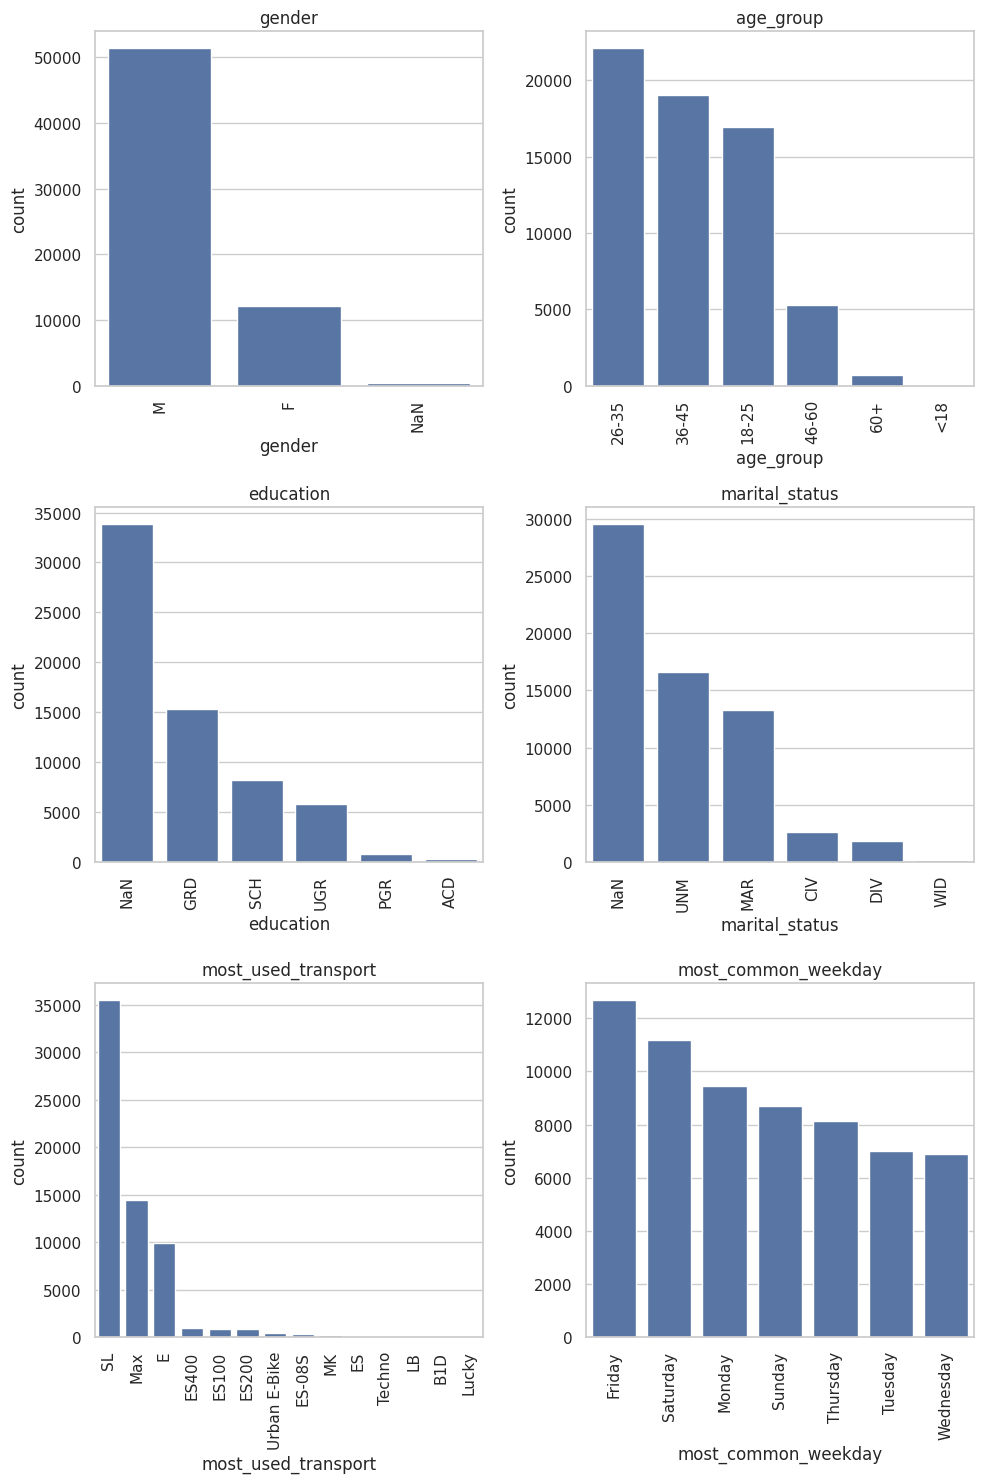

In [ ]:
user_objects_min=['gender', 'age_group', 'education', 'marital_status', 'most_used_transport', 'most_common_weekday']

plt.figure(figsize=(10, 15))
for i in range(6):
    plt.subplot(3, 2, i+1)
    temp_data = user_df[user_objects_min[i]].fillna('NaN')
    sns.countplot(data=temp_data.to_frame(), x=user_objects_min[i],
                  order=temp_data.value_counts().index)

    plt.title(user_objects_min[i])
    plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

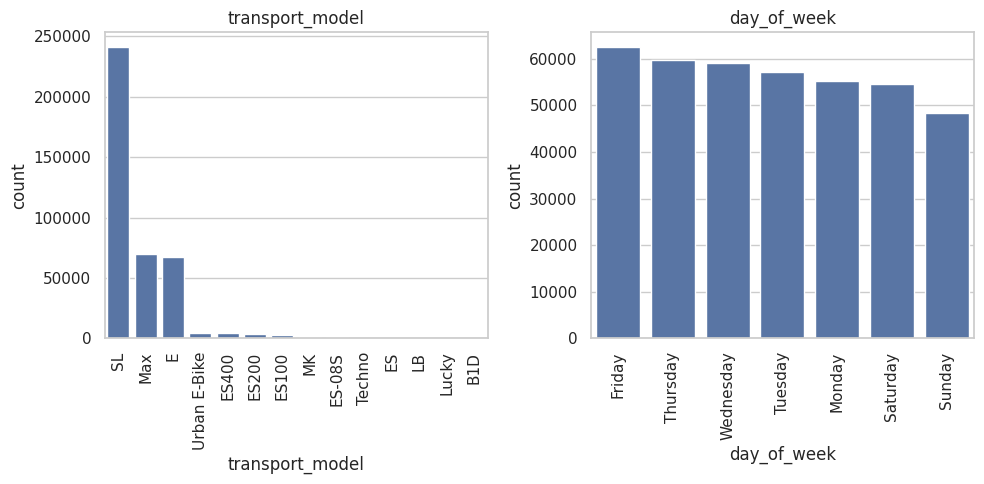

In [ ]:
object_min =['transport_model','day_of_week']

plt.figure(figsize=(10, 5))
for i in range(2):
    plt.subplot(1, 2, i+1)
    temp_data = data[object_min[i]].fillna('NaN')
    sns.countplot(data=temp_data.to_frame(), x=object_min[i],
                  order=temp_data.value_counts().index)

    plt.title(object_min[i])
    plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

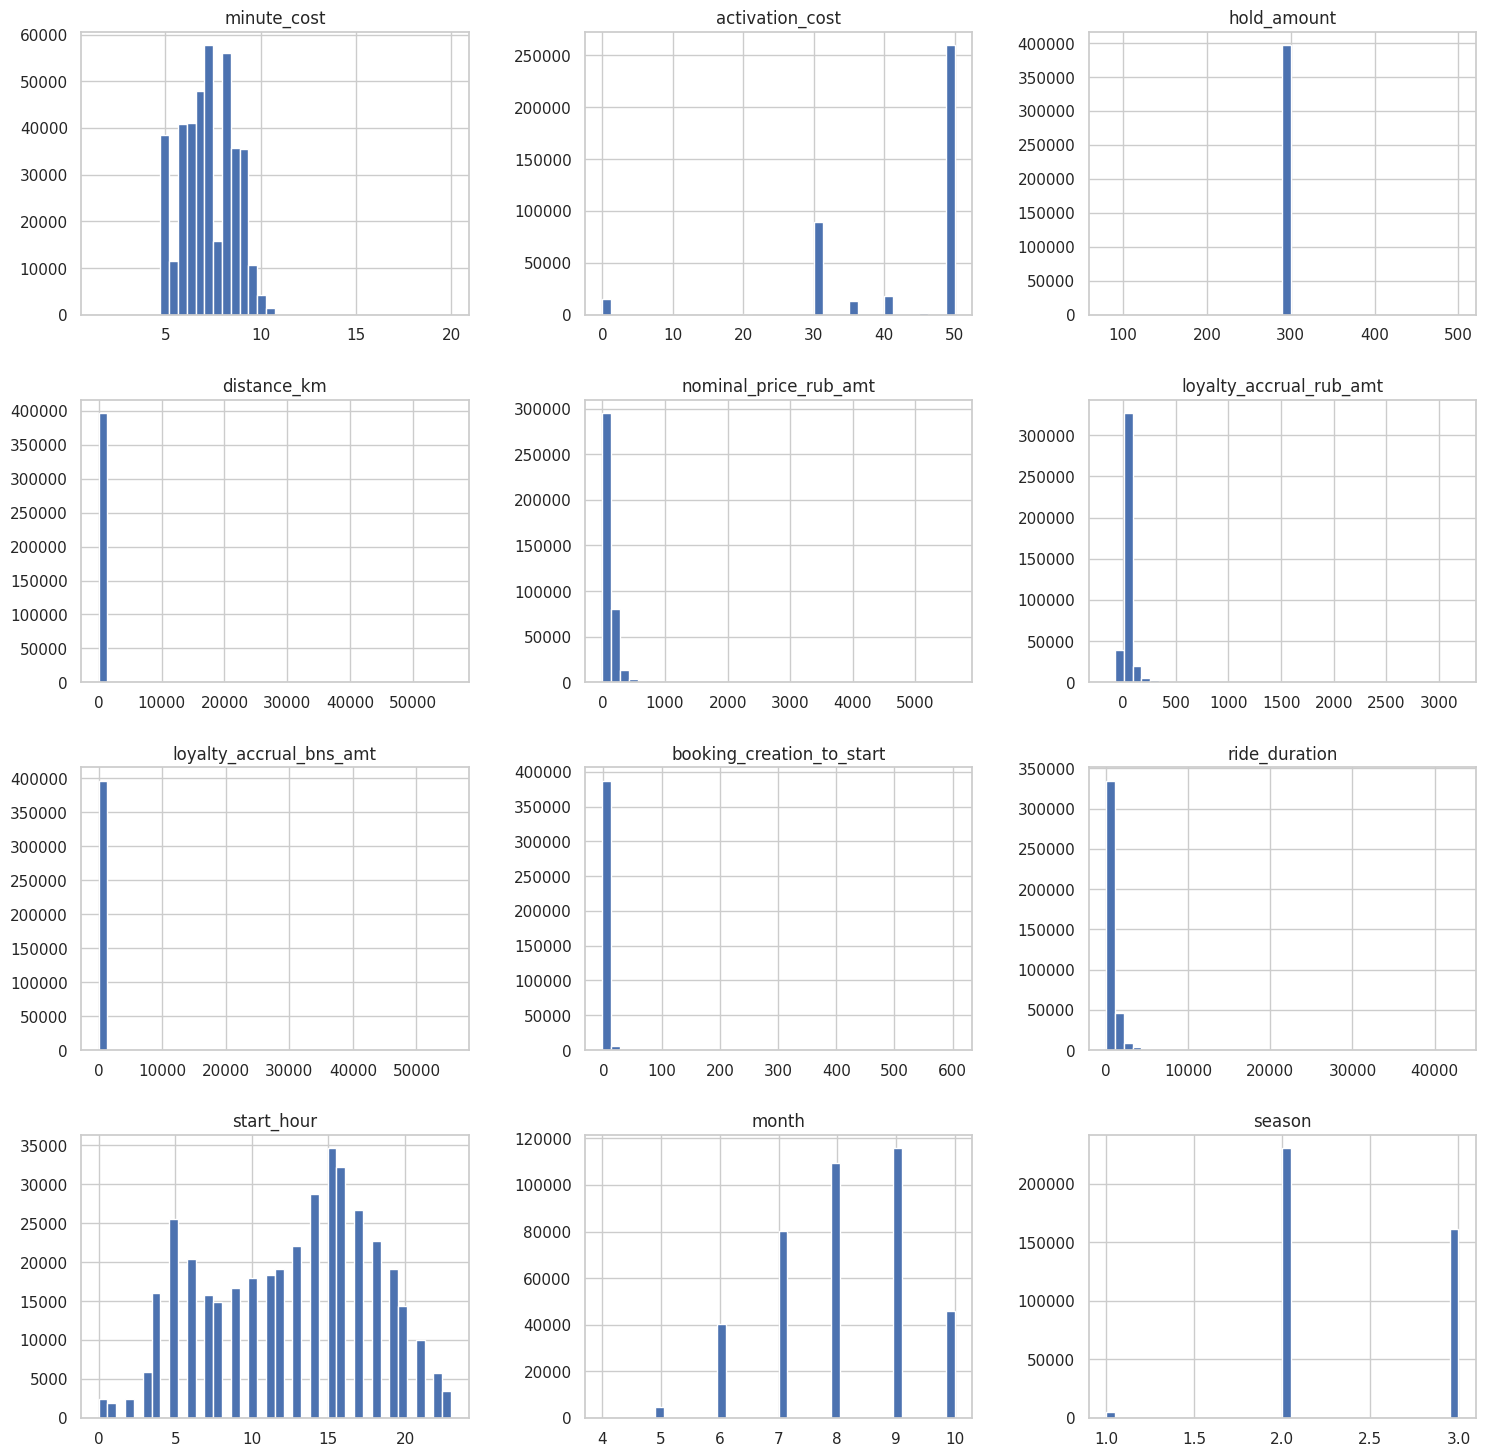

In [ ]:
data_int[['minute_cost', 'activation_cost', 'hold_amount',
       'distance_km', 'nominal_price_rub_amt', 'loyalty_accrual_rub_amt', 'loyalty_accrual_bns_amt',
       'booking_creation_to_start', 'ride_duration', 'start_hour', 'month','season']].hist(figsize=(18, 18), bins=40);

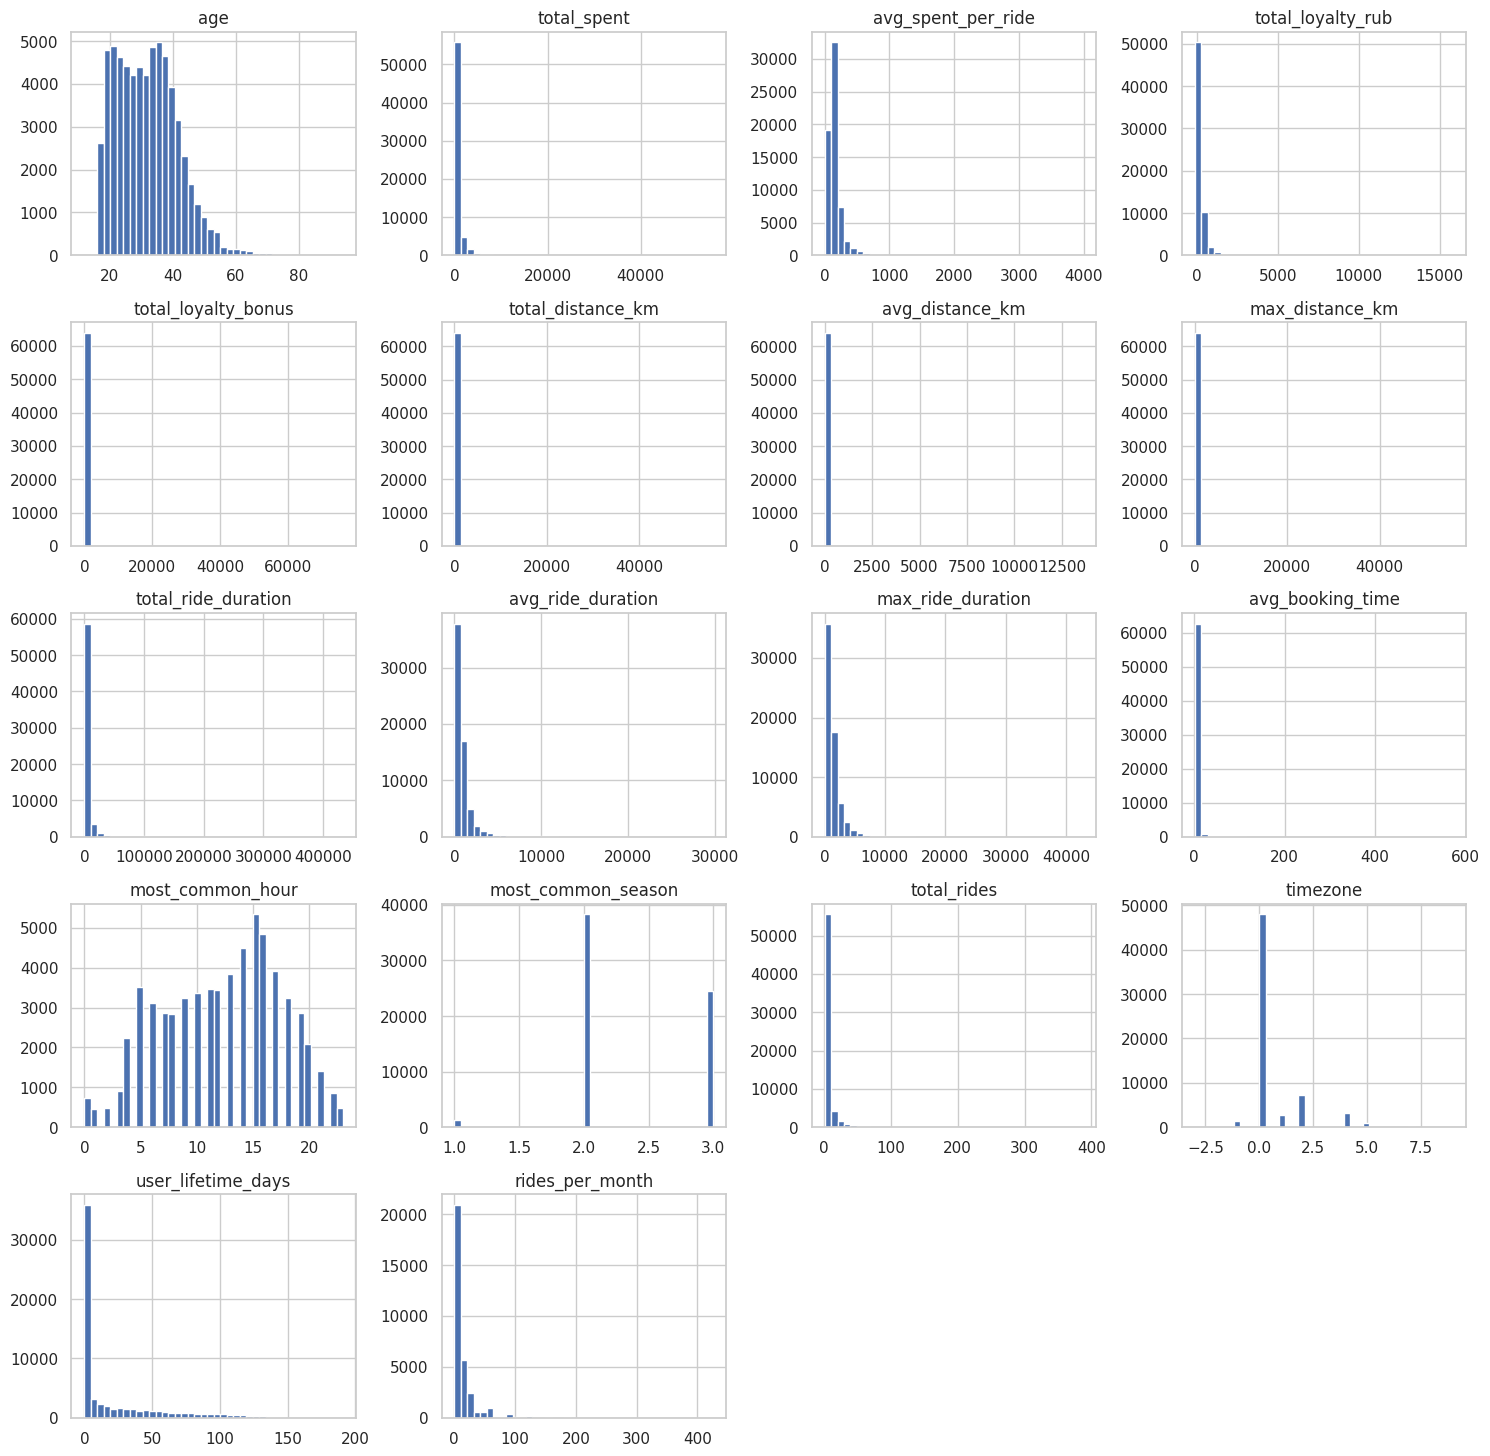

In [ ]:
user_int[['age', 'total_spent', 'avg_spent_per_ride',
       'total_loyalty_rub', 'total_loyalty_bonus', 'total_distance_km',
       'avg_distance_km', 'max_distance_km', 'total_ride_duration',
       'avg_ride_duration', 'max_ride_duration', 'avg_booking_time',
       'most_common_hour', 'most_common_season', 'total_rides', 'timezone',
       'user_lifetime_days', 'rides_per_month']].hist(figsize=(18, 18), bins=40);

In [205]:
minute_counts = pd.DataFrame({
    'minute': range(60),
    'starts': data['local_book_start_dttm'].dt.minute.value_counts().sort_index(),
    'ends': data['local_book_end_dttm'].dt.minute.value_counts().sort_index()
}).fillna(0)

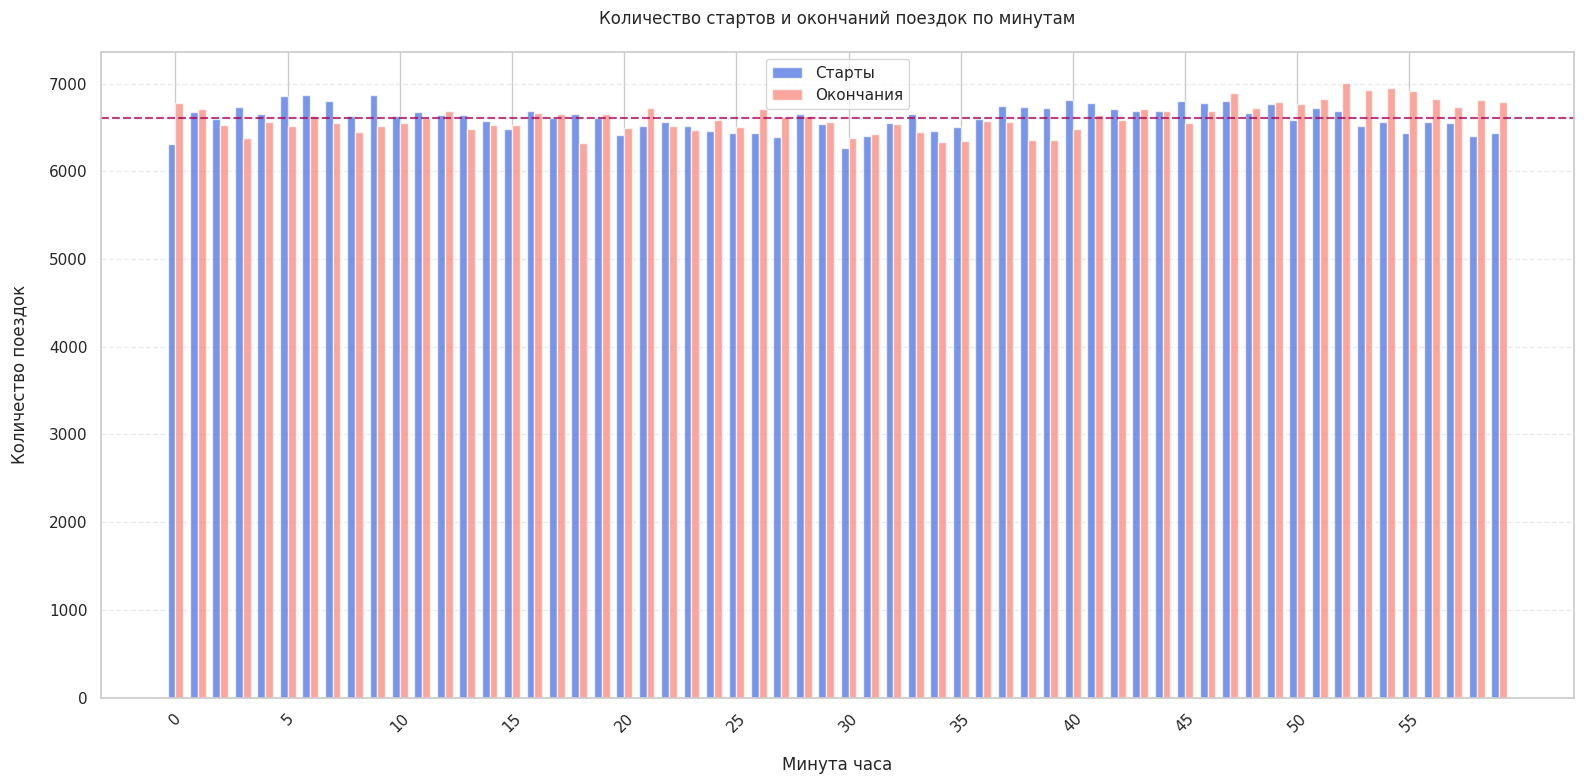

In [207]:
plt.figure(figsize=(16, 8))

bar_width = 0.35

x = np.arange(60)

plt.bar(x - bar_width/2, minute_counts['starts'], width=bar_width,
        color='royalblue', alpha=0.7, label='Старты')
plt.bar(x + bar_width/2, minute_counts['ends'], width=bar_width,
        color='salmon', alpha=0.7, label='Окончания')

plt.title('Количество стартов и окончаний поездок по минутам', pad=20)
plt.xlabel('Минута часа', labelpad=15)
plt.ylabel('Количество поездок', labelpad=15)
plt.xticks(x[::5], rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend()

# добавляем средние линии
plt.axhline(minute_counts['starts'].mean(), color='blue', linestyle='--', alpha=0.5)
plt.axhline(minute_counts['ends'].mean(), color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

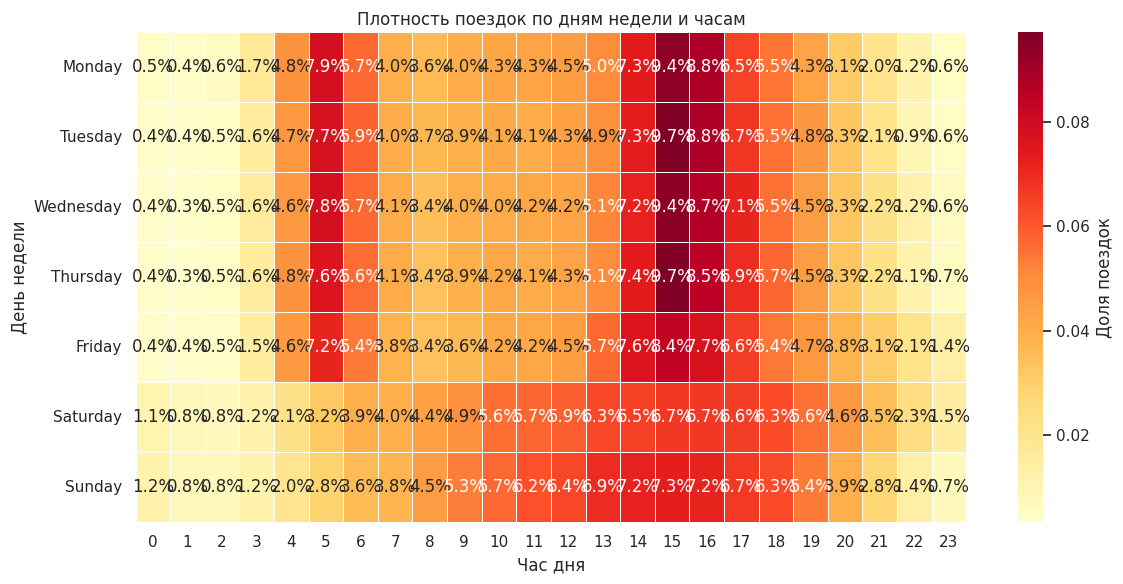

In [ ]:
weekday_order =['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
data['day_of_week'] = pd.Categorical(data['day_of_week'],
                                   categories=weekday_order,
                                   ordered=True)

plt.figure(figsize=(12, 6))
heatmap_data = pd.crosstab(
    data['day_of_week'],
    data['start_hour'],
    normalize='index'
)

sns.heatmap(
    heatmap_data,
    cmap='YlOrRd',
    linewidths=0.5,
    annot=True,
    fmt='.1%',
    cbar_kws={'label': 'Доля поездок'}
)

plt.title('Плотность поездок по дням недели и часам')
plt.xlabel('Час дня')
plt.ylabel('День недели')
plt.tight_layout()
plt.show()

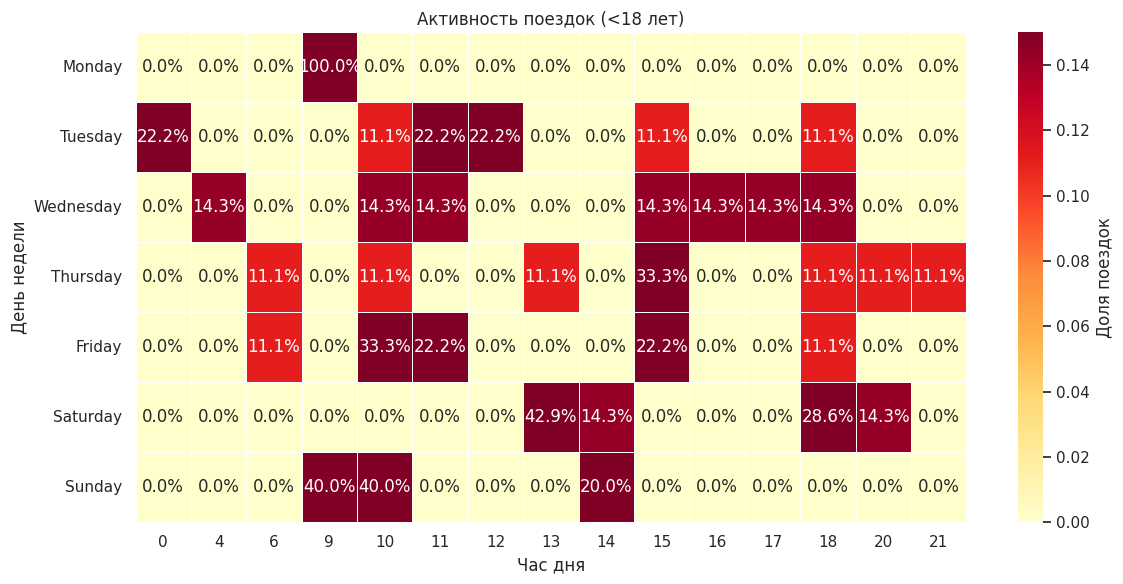

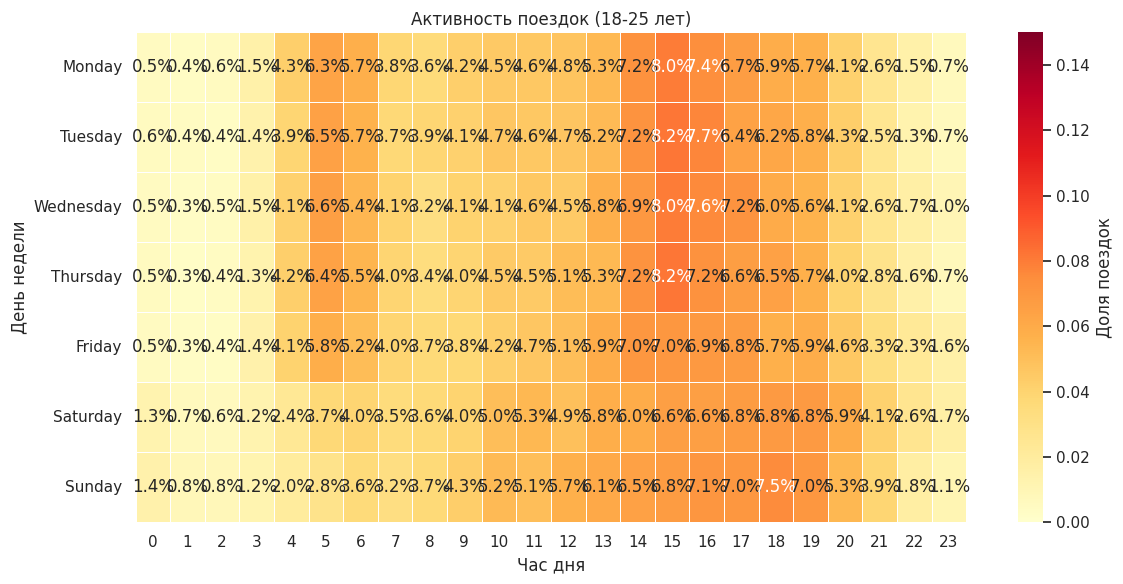

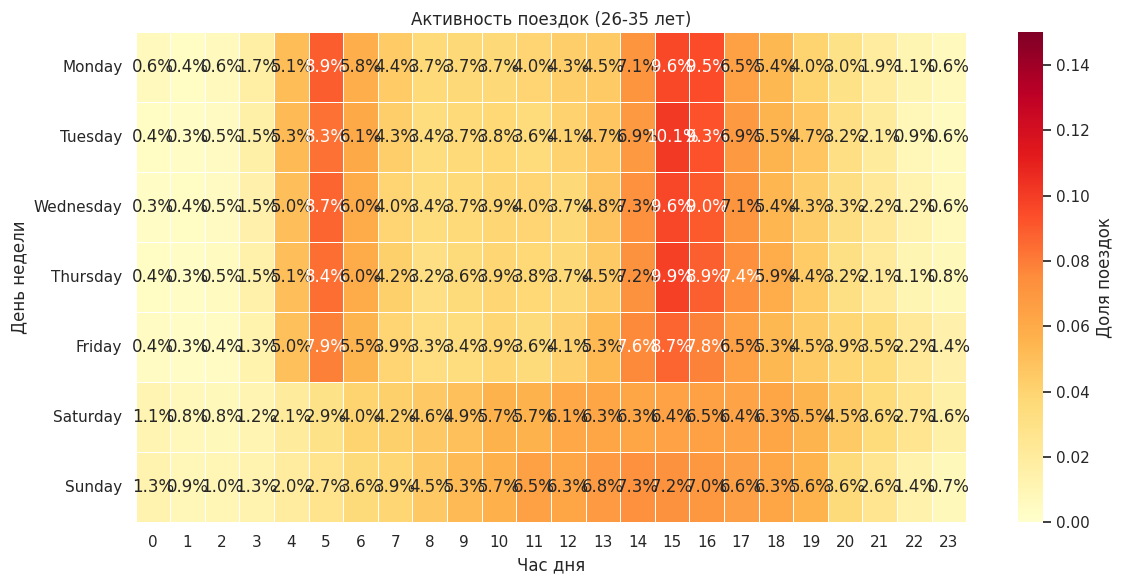

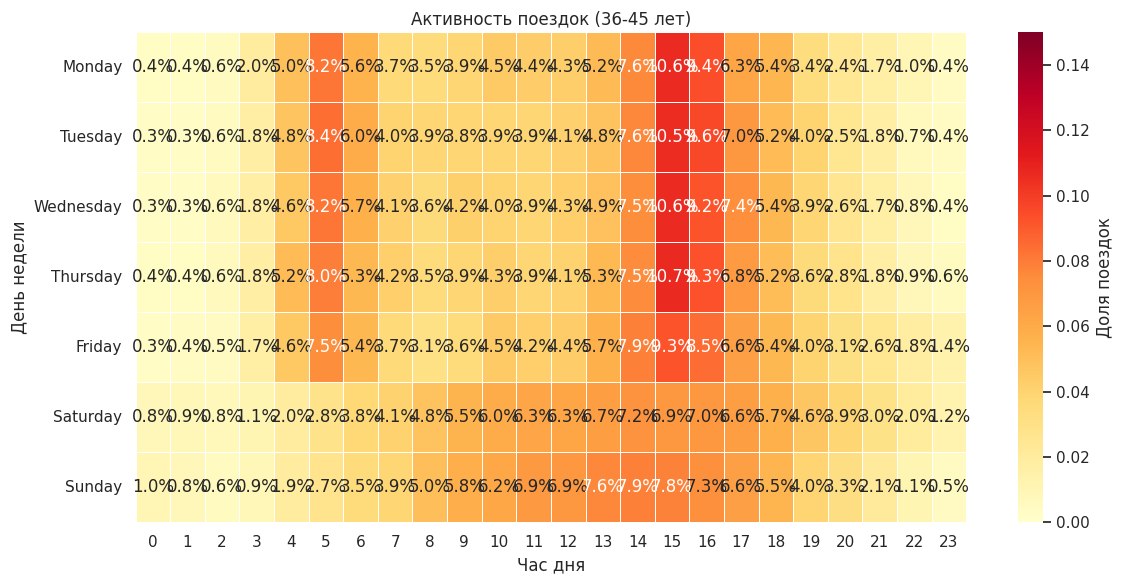

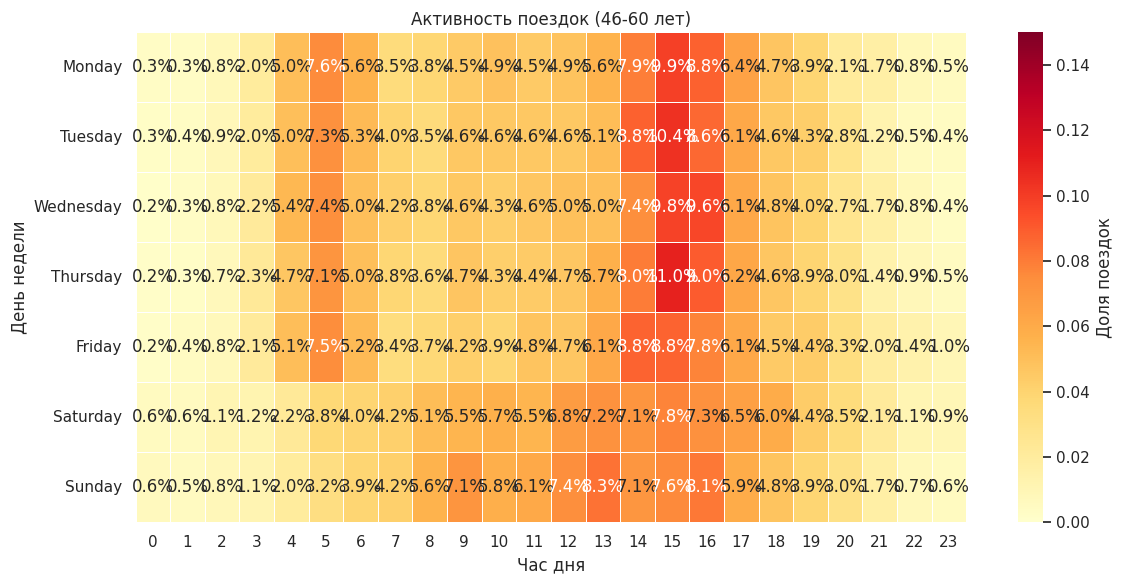

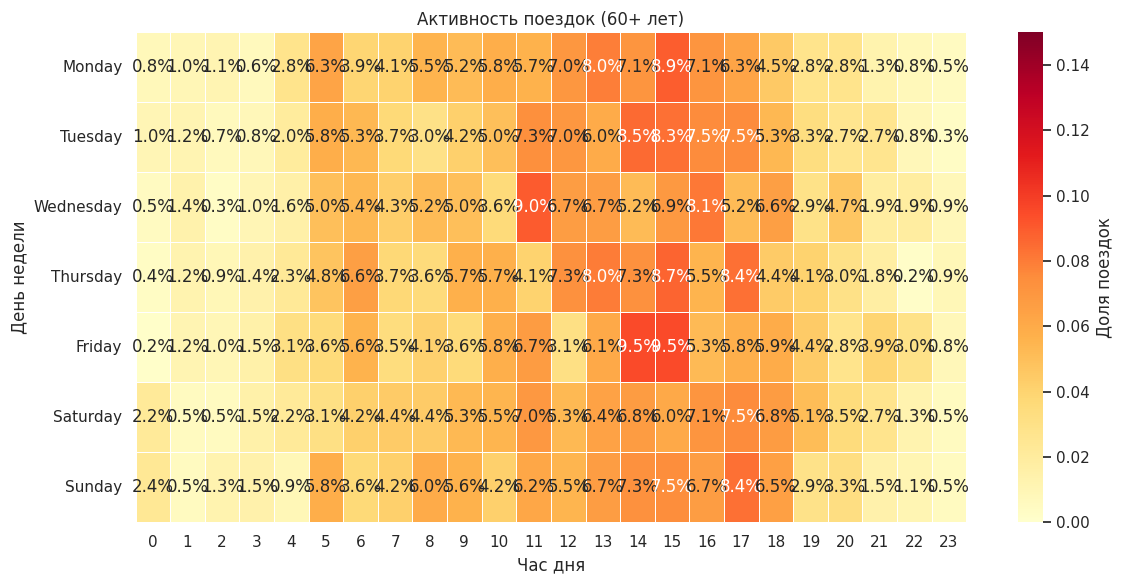

In [ ]:
for age_group in labels:
    subset = data[data['age_group'] == age_group]

    heatmap_data = pd.crosstab(
        subset['day_of_week'],
        subset['start_hour'],
        normalize='index'
    )

    plt.figure(figsize=(12, 6))

    sns.heatmap(
        heatmap_data,
        cmap='YlOrRd',
        linewidths=0.5,
        annot=True,
        fmt='.1%',
        cbar_kws={'label': 'Доля поездок'},
        vmin=0,
        vmax=0.15  # Максимальное значение для цветовой шкалы
    )

    plt.title(f'Активность поездок ({age_group} лет)')
    plt.xlabel('Час дня')
    plt.ylabel('День недели')
    plt.tight_layout()
    plt.show()

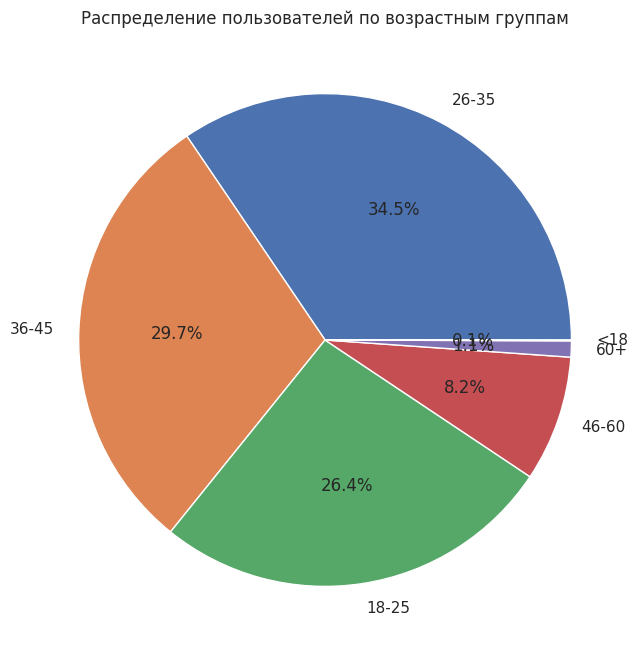

In [ ]:
age_counts = user_df['age_group'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(age_counts, labels=age_counts.index, autopct='%1.1f%%')
plt.title('Распределение пользователей по возрастным группам')
plt.show()

<ipython-input-150-55b0c809fbc3>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


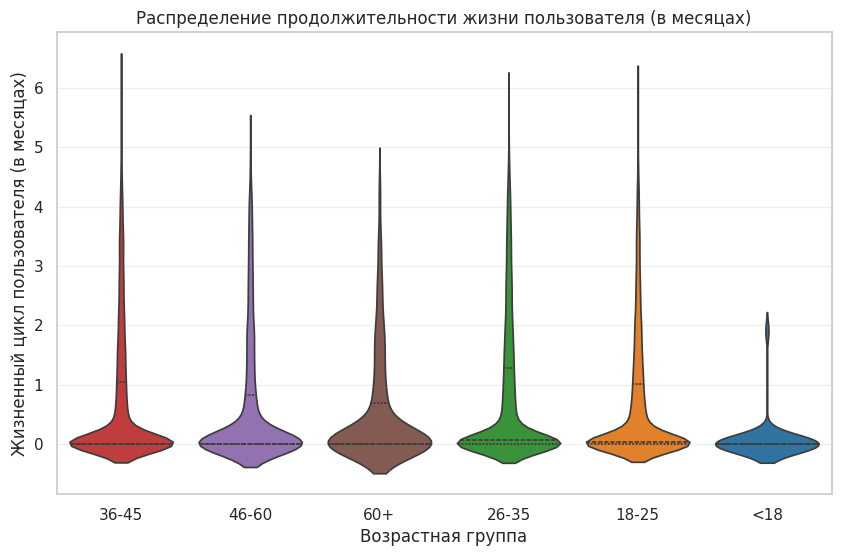

In [ ]:
plt.figure(figsize=(10, 6))
sns.violinplot(
    data=user_df,
    x='age_group',
    y=user_df['user_lifetime_days'] / 30.44,
    palette=age_group_palette,
    inner='quartile'
)
plt.title('Распределение продолжительности жизни пользователя (в месяцах)')
plt.ylabel('Жизненный цикл пользователя (в месяцах)')
plt.xlabel('Возрастная группа')
plt.grid(axis='y', alpha=0.3)
plt.show()


<ipython-input-152-84d861873897>:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data=data.groupby('day_of_week')['ride_duration'].mean().reset_index(),


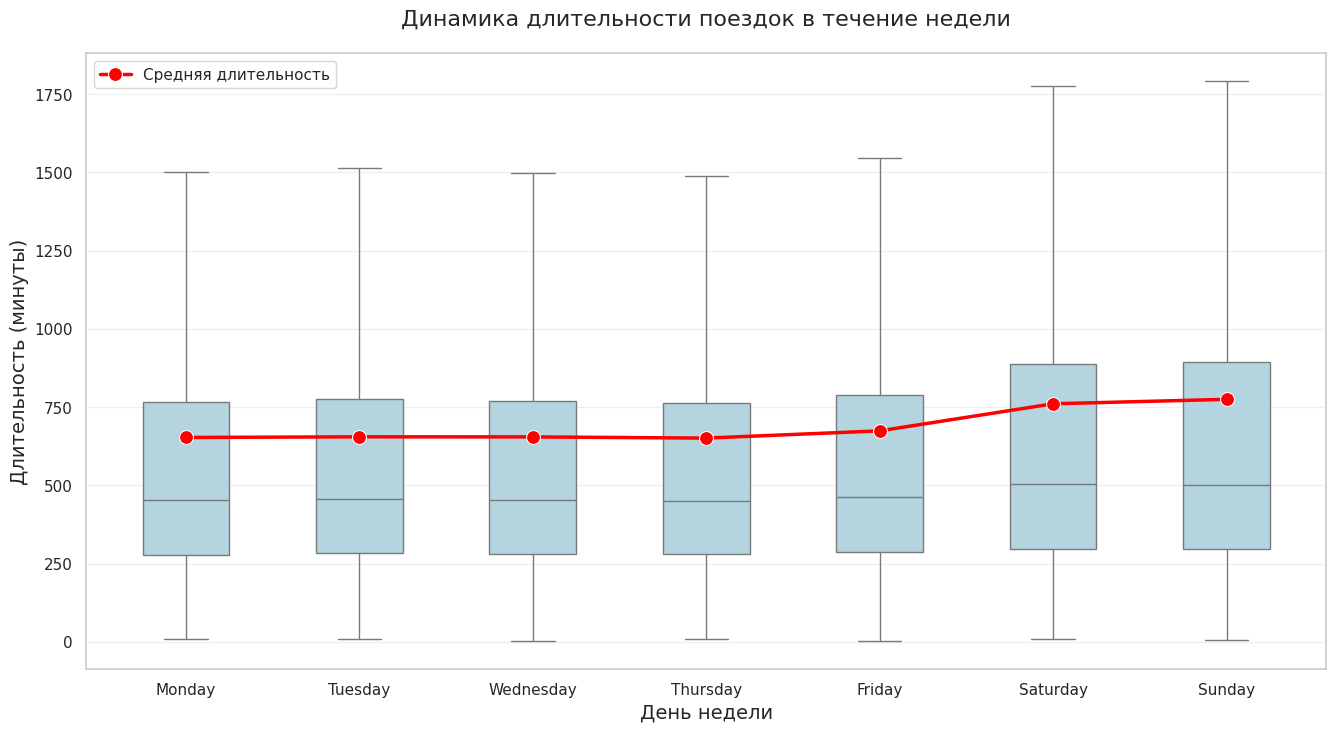

In [ ]:
plt.figure(figsize=(16, 8))

sns.boxplot(
    data=data,
    x='day_of_week',
    y='ride_duration',
    color='lightblue',
    showfliers=False,
    width=0.5
)

# средние значения
sns.lineplot(
    data=data.groupby('day_of_week')['ride_duration'].mean().reset_index(),
    x='day_of_week',
    y='ride_duration',
    color='red',
    marker='o',
    markersize=10,
    linewidth=2.5,
    label='Средняя длительность'
)

plt.title('Динамика длительности поездок в течение недели', pad=20, fontsize=16)
plt.xlabel('День недели', fontsize=14)
plt.ylabel('Длительность (минуты)', fontsize=14)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

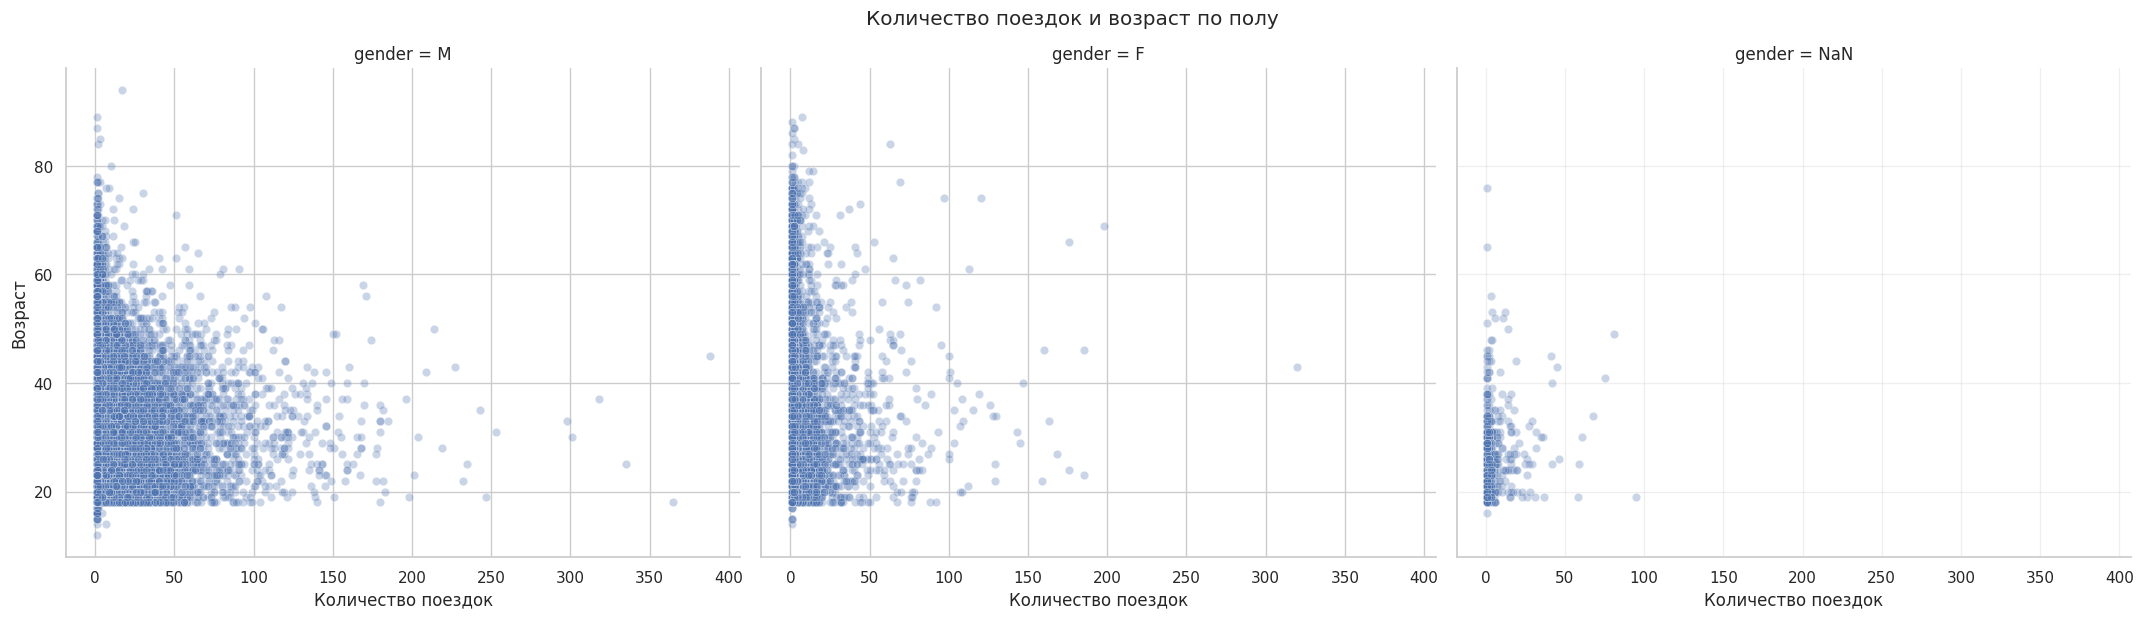

In [ ]:
g = sns.FacetGrid(user_df, col='gender', height=6, aspect=1.2)
g.map_dataframe(sns.scatterplot, x='total_rides', y='age', alpha=0.3)
g.set_axis_labels("Количество поездок", "Возраст")
g.fig.suptitle('Количество поездок и возраст по полу', y=1.03)
plt.grid(alpha=0.3)
plt.show()


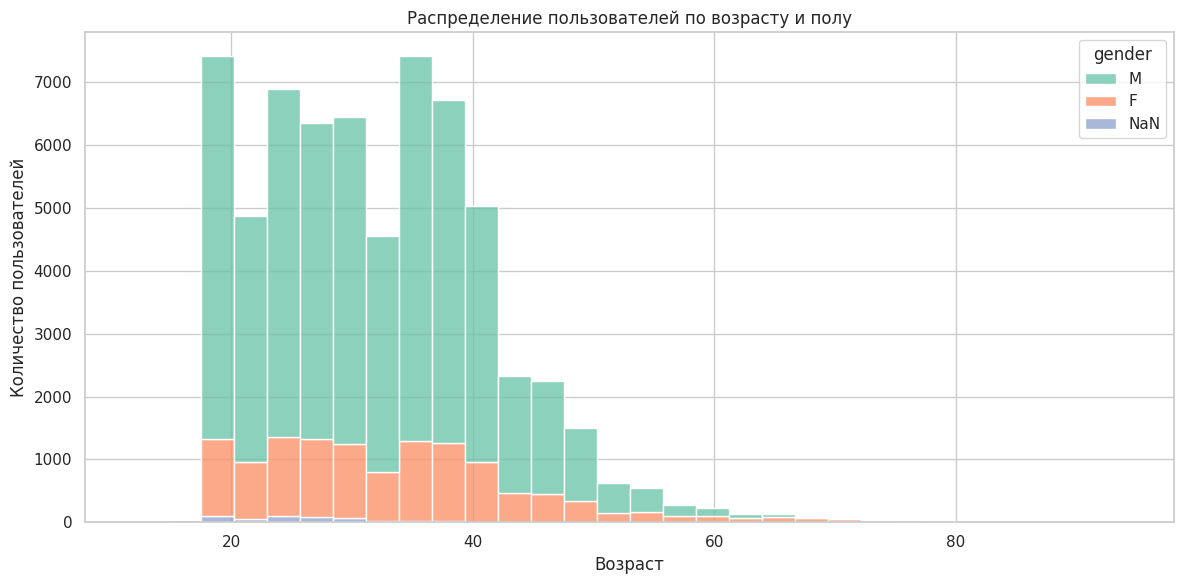

In [ ]:
plt.figure(figsize=(12, 6))

sns.histplot(
    data=user_df,
    x='age',
    hue='gender',
    multiple='stack',
    bins=30,
    palette='Set2'
)

plt.title('Распределение пользователей по возрасту и полу')
plt.xlabel('Возраст')
plt.ylabel('Количество пользователей')
plt.tight_layout()
plt.show()


<ipython-input-184-89c5ac533cba>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=user_df, x='age_group', y='user_lifetime_days', palette='Set3')


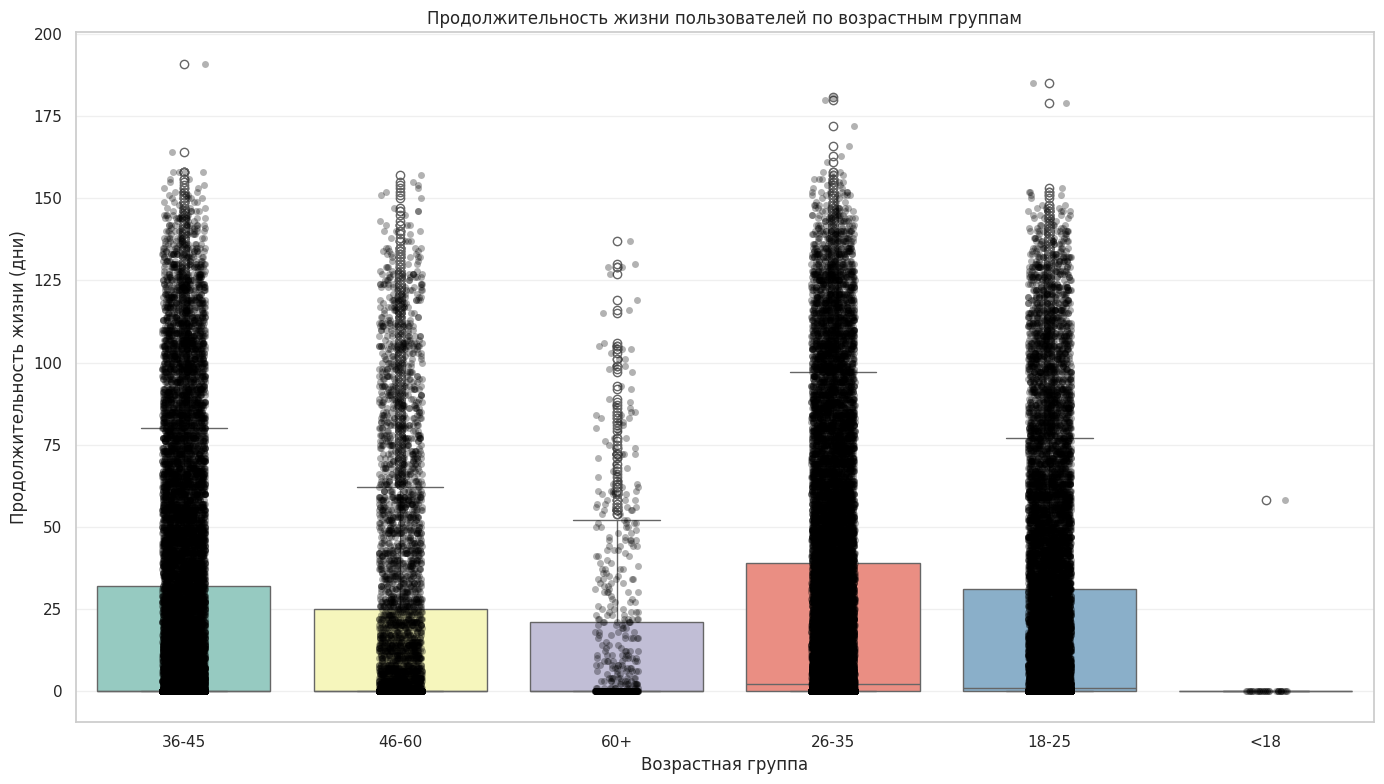

In [184]:
plt.figure(figsize=(14, 8))
sns.boxplot(data=user_df, x='age_group', y='user_lifetime_days', palette='Set3')
sns.stripplot(data=user_df, x='age_group', y='user_lifetime_days', color='black', alpha=0.3)
plt.title('Продолжительность жизни пользователей по возрастным группам')
plt.xlabel('Возрастная группа')
plt.ylabel('Продолжительность жизни (дни)')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


<ipython-input-204-6424bdc49b67>:9: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



<Figure size 1400x800 with 0 Axes>

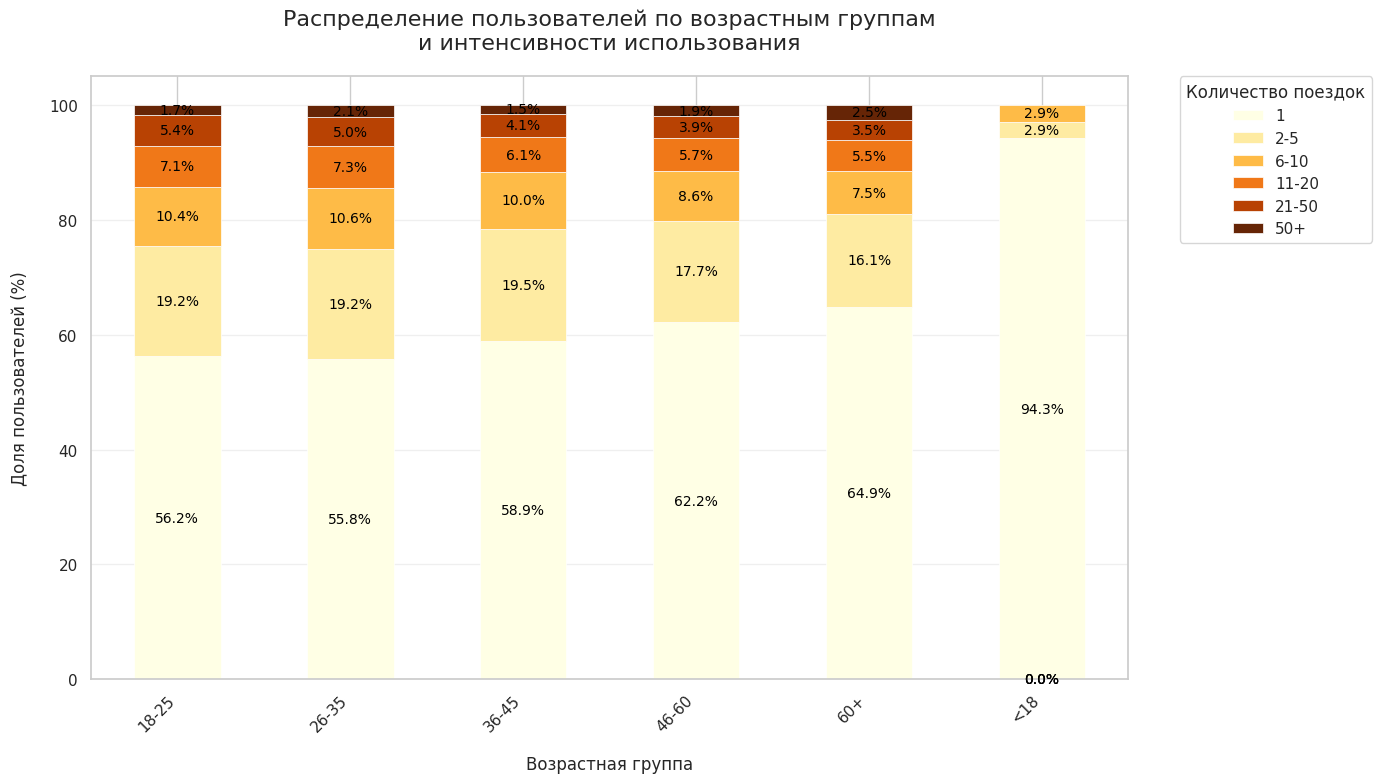

In [204]:
plt.figure(figsize=(14, 8))

usage_bins = pd.cut(user_df['total_rides'],
                   bins=[0, 2, 5, 10, 20, 50, float('inf')],
                   labels=['1', '2-5', '6-10', '11-20','21-50', '50+'])

heatmap_data = user_df.groupby(['age_group', usage_bins]).size().unstack()

heatmap_data = heatmap_data.div(heatmap_data.sum(axis=1), axis=0) * 100 #нормализуем по строкам для процентного отображения

ax = heatmap_data.plot(kind='bar',
                      stacked=True,
                      colormap='YlOrBr',
                      edgecolor='white',
                      linewidth=0.5,
                      figsize=(14, 8))

plt.title('Распределение пользователей по возрастным группам\nи интенсивности использования', pad=20, fontsize=16)
plt.xlabel('Возрастная группа', labelpad=15)
plt.ylabel('Доля пользователей (%)', labelpad=15)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

for container in ax.containers:
    ax.bar_label(container,
                label_type='center',
                fmt='%.1f%%',
                color='black',
                fontsize=10)

plt.legend(title='Количество поездок',
          bbox_to_anchor=(1.05, 1),
          borderaxespad=0)

plt.tight_layout()
plt.show()

<ipython-input-199-8c27568cc3a5>:16: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

<ipython-input-199-8c27568cc3a5>:16: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

<ipython-input-199-8c27568cc3a5>:16: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

<ipython-input-199-8c27568cc3a5>:16: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

<ipython-input-199-8c27568cc3a5>:16: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

<ipython-input-199-8c27568cc3a5>:16: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.

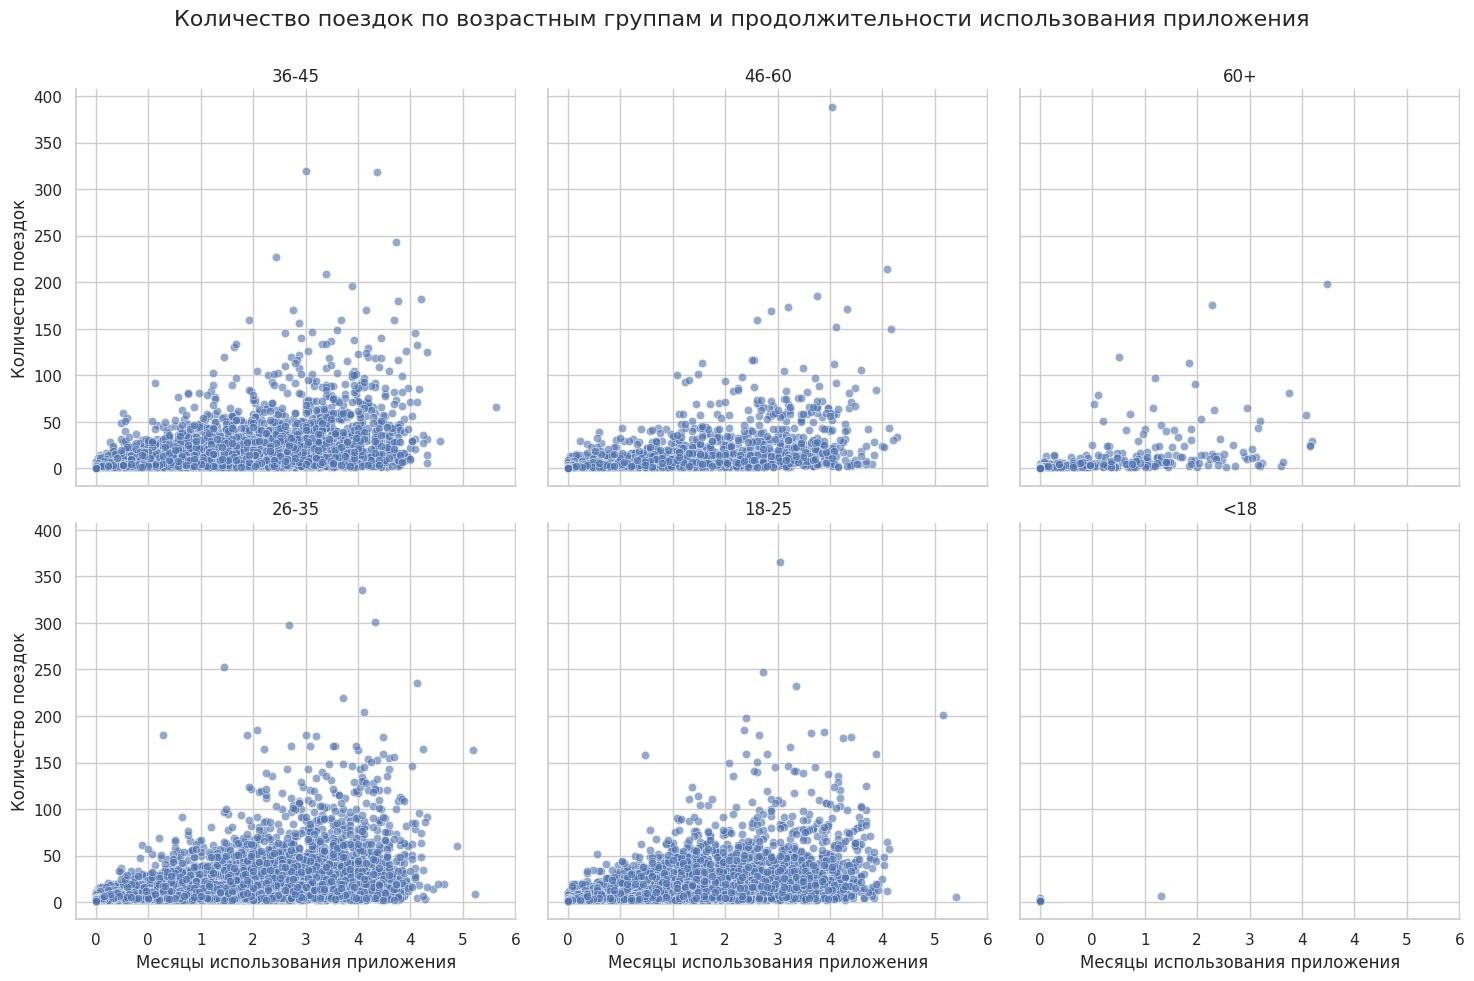

In [199]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.FacetGrid(user_df, col='age_group', col_wrap=3, height=5)
g.map(sns.scatterplot, 'user_lifetime_days', 'total_rides', alpha=0.6)

g.set_axis_labels('Месяцы использования приложения', 'Количество поездок')
g.set_titles(col_template='{col_name}')

#преобразуем дни в месяцы на оси X
for ax in g.axes.flat:
    ax.set_xticklabels([int(label/30.44) for label in ax.get_xticks()])

plt.subplots_adjust(top=0.9)
g.fig.suptitle('Количество поездок по возрастным группам и продолжительности использования приложения', fontsize=16)

plt.show()
